# CBA 2026 — Notebook 05: MOSA imputation diagnostics

Validates that MOSA itself is faithful before any downstream prediction claims. Builds Figs P9–P11:

| Fig | What it shows |
| --- | --- |
| P9 | Imputation accuracy on held-out CCMA cells per omic (measured vs MOSA-imputed scatter, Pearson r and n in each panel). |
| P10 | Imputation scope — per-omic measured-vs-after-MOSA cohort coverage, plus a performance-vs-cohort-size scatter for context. |
| P11 | CNV-vs-no-CNV ablation — bar chart of mean Pearson r at the headline condition, plus a per-target scatter (no-CNV vs with-CNV). Compares run `20260313_162348` (no-CNV MOSA) against the selected `20260511_174623` (with-CNV). |

Outputs: `reports/cba2026_claude_union/prediction_analysis/20260511_174623/` (composites) and `…/singles/` (single-panel slide cuts).

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd()))

import _prediction_analysis as pred
from IPython.display import Image, display
import pandas as pd

summary_long = pred.load_summary_long()

## Figure P9 — imputation accuracy per omic

Pulls held-out CCMA test cells (`data/clines/ccma_processed/{omic}_ccma_mosa_test.csv`) and the matching MOSA reconstruction (`reports/vae/files/{TIMESTAMP}_imputed_{omic}_test_all.csv.gz`), then plots measured vs MOSA-imputed for every measured value across all features × cells.

In [2]:
p9, p9_summary = pred.figP9_imputation_accuracy()
p9_summary.round(3)

,omic,pearson_r,n_pairs,n_cells,n_features
0,crisprcas9,0.747,11932,24,500
1,drugresponse,0.788,11951,24,500
2,copynumber,0.466,14544,24,606
3,transcriptomics,0.939,363384,24,15141
4,methylation,0.941,290095,24,12116


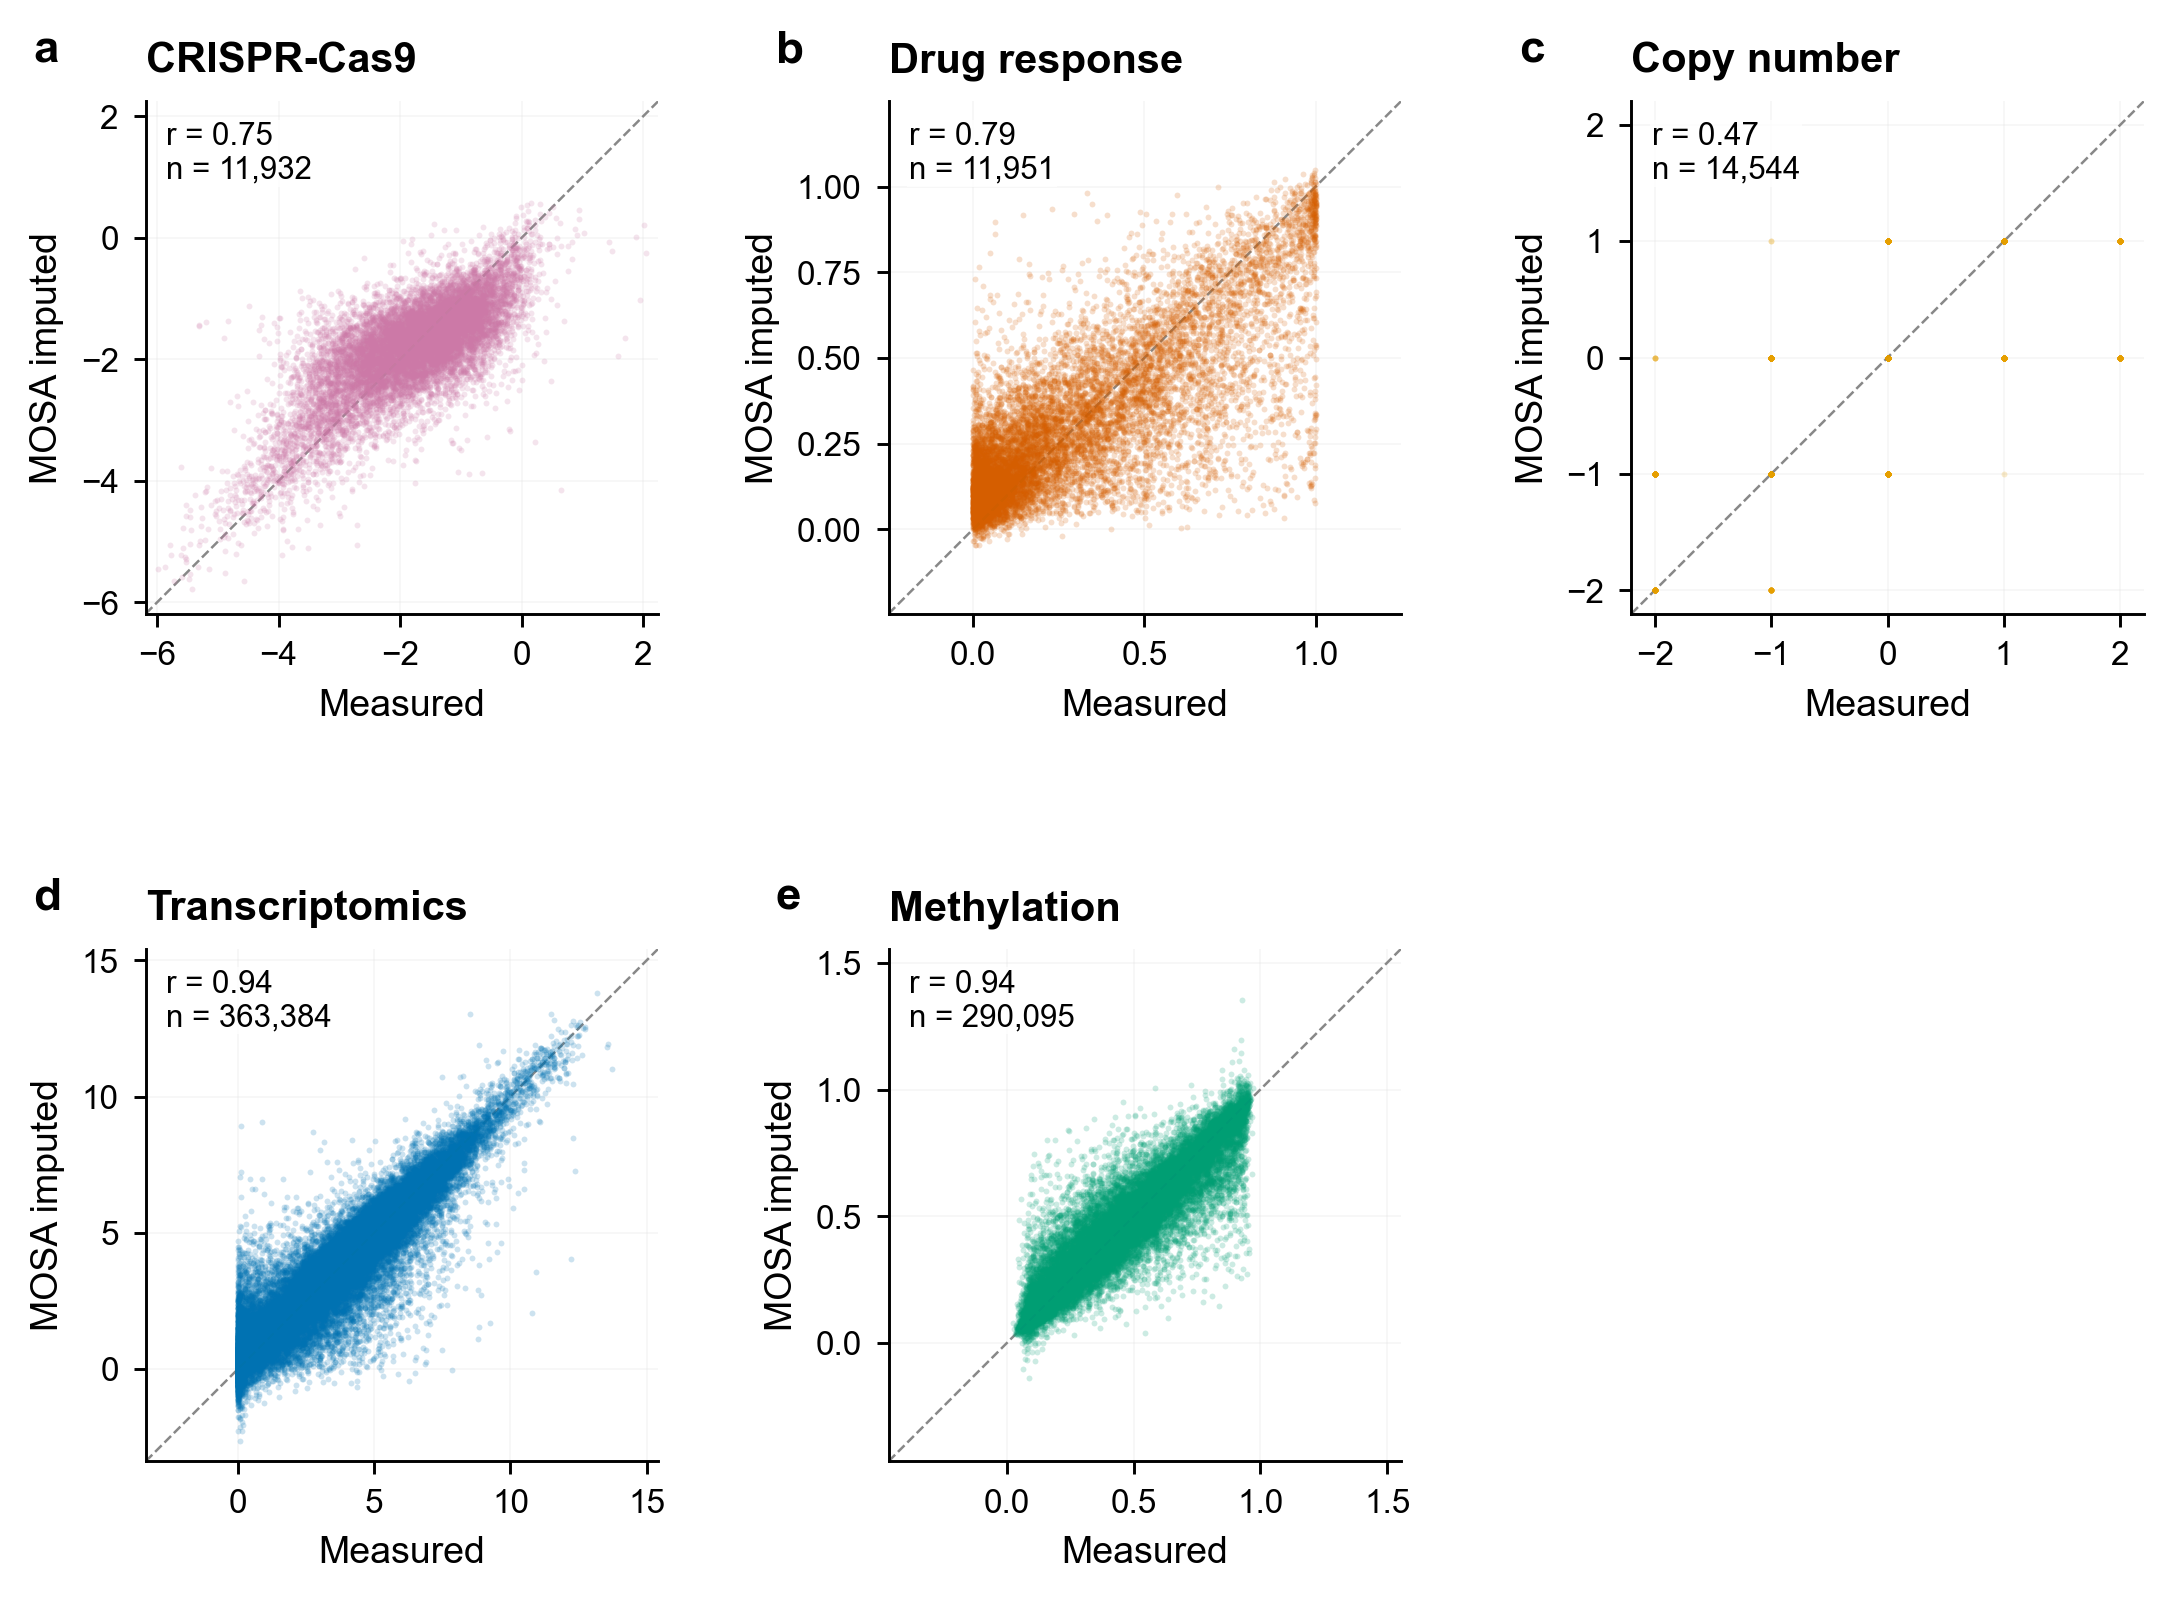

reports/cba2026_claude_union/prediction_analysis/20260511_174623/figP9_imputation_accuracy.pdf


In [3]:
display(Image(filename=str(p9.with_suffix(".png"))))
print(p9.relative_to(pred.ROOT))

## Figure P10 — imputation scope

Shows the gap MOSA closes — measured cell coverage per omic and the cohort size after imputation.

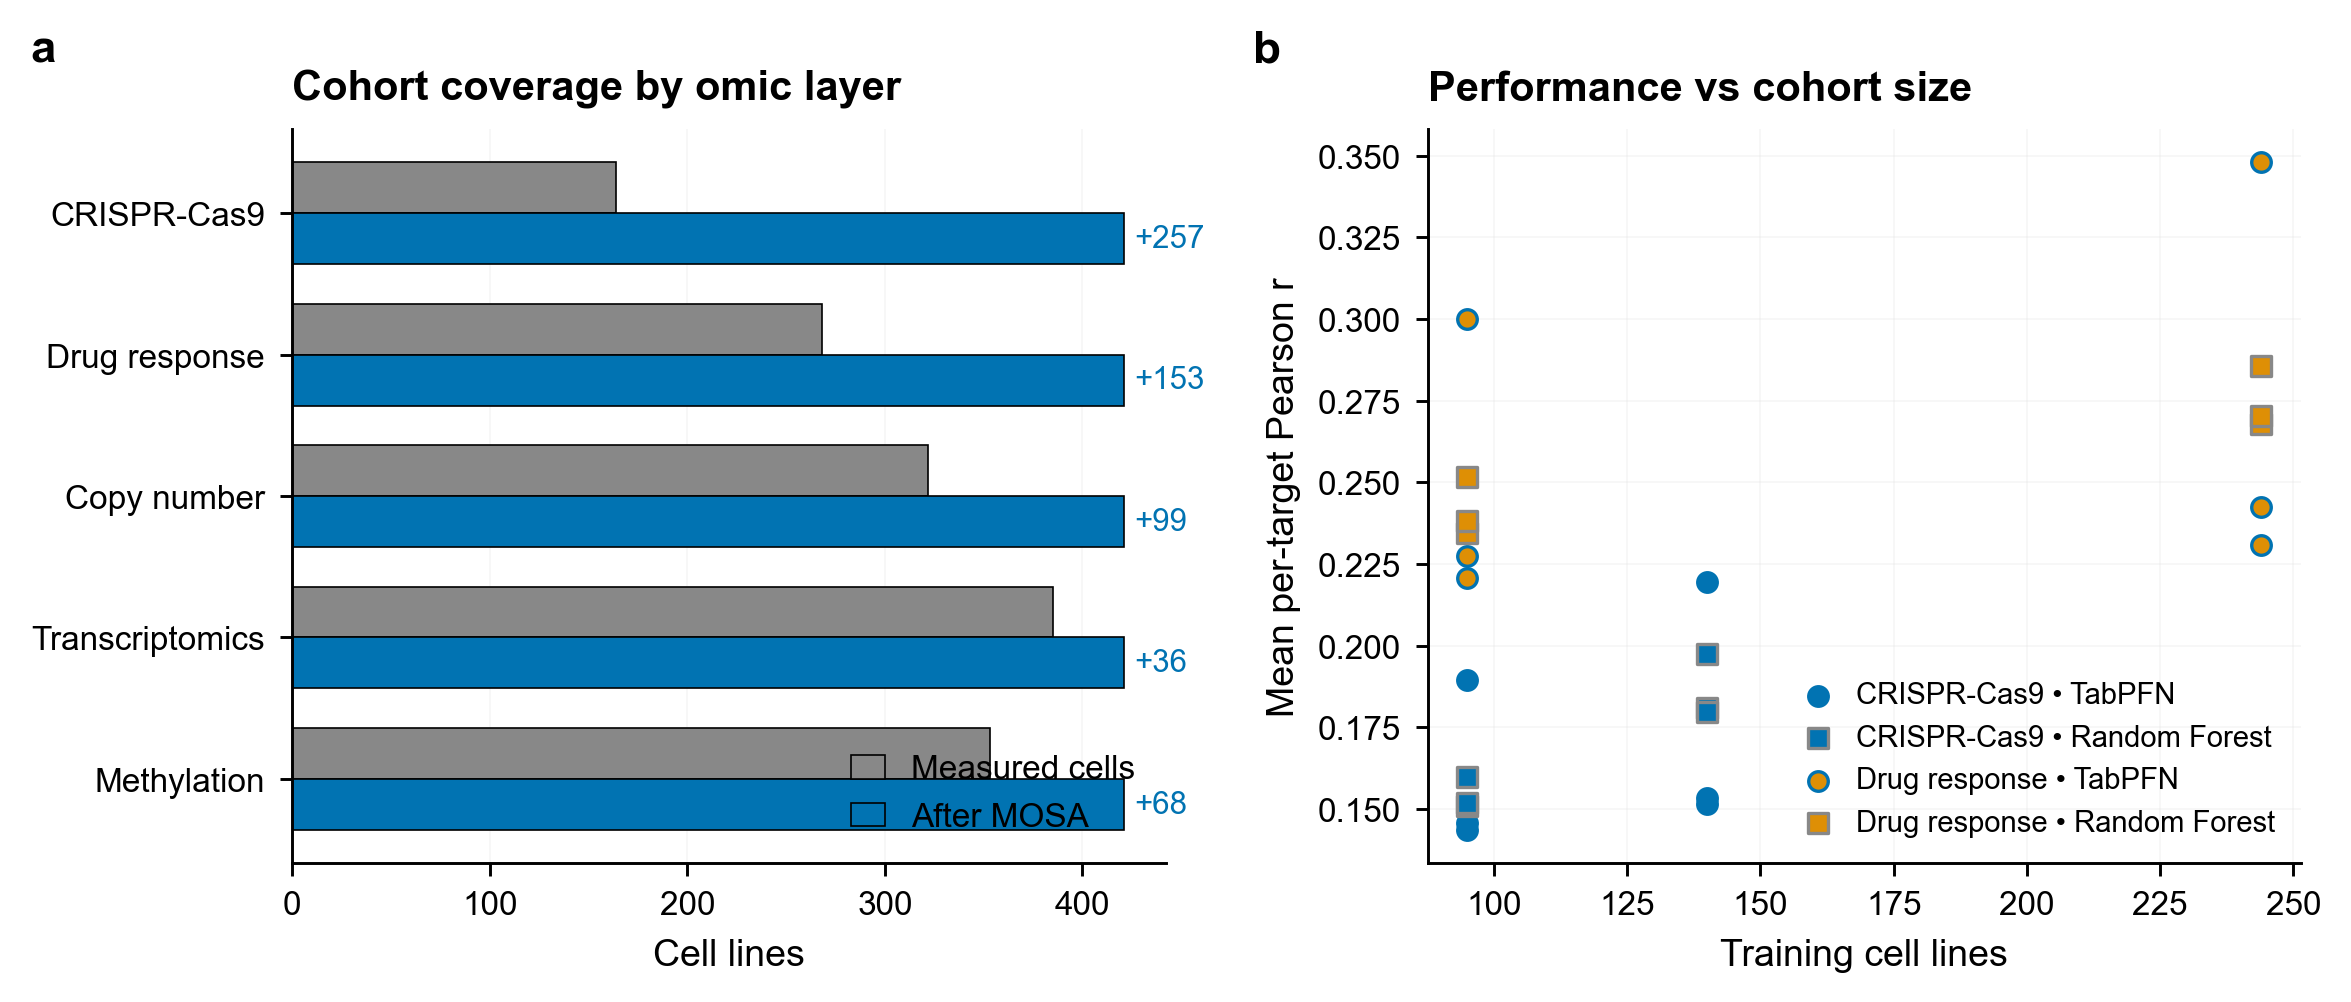

,omic_layer,n_cells_measured,n_features,n_cells_after_mosa,n_cells_added_by_mosa
0,crisprcas9,164,500,421,257
1,drugresponse,268,500,421,153
2,copynumber,322,606,421,99
3,transcriptomics,385,15141,421,36
4,methylation,353,12146,421,68


In [4]:
p10 = pred.figP10_imputation_scope(summary_long)
display(Image(filename=str(p10.with_suffix(".png"))))
scope = pred.load_imputation_scope()
scope

## Figure P11 — CNV vs no-CNV MOSA ablation

Compares the headline condition (`expanded × mosa_all`) at MOSA training run `20260511_174623` (with copy number) against `20260313_162348` (no copy number). Panel a — mean per-target Pearson r per family × model. Panel b — paired per-target scatter; points above the diagonal show targets that benefit from including CNV in MOSA training.

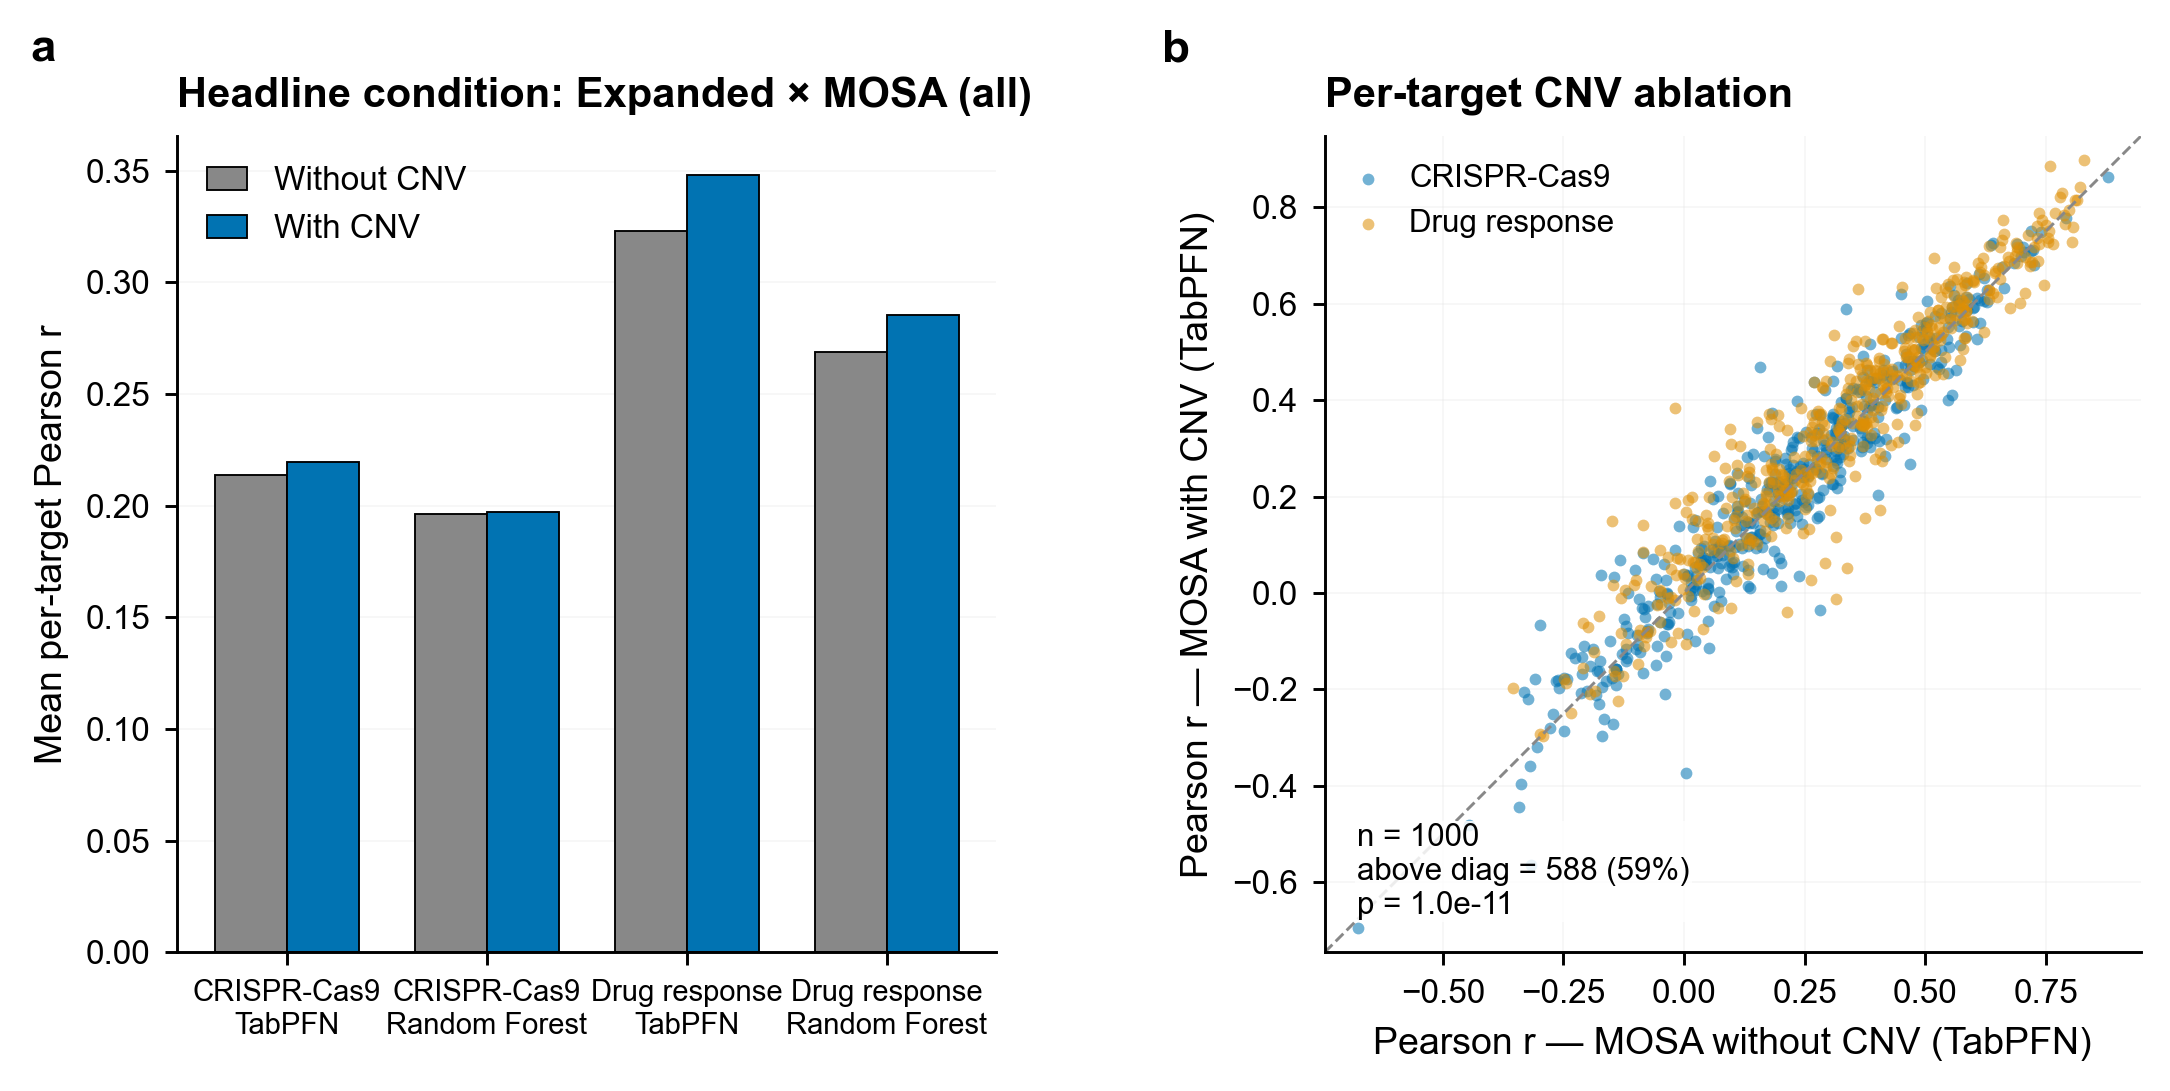

reports/cba2026_claude_union/prediction_analysis/20260511_174623/figP11_cnv_ablation.pdf


In [5]:
p11 = pred.figP11_cnv_ablation()
if p11 is not None:
    display(Image(filename=str(p11.with_suffix(".png"))))
    print(p11.relative_to(pred.ROOT))
else:
    print("Older non-CNV run not found; ablation skipped.")

## Slide-friendly singles + accuracy-per-omic table

In [6]:
singles = [pred.single_figP10a_scope(summary_long)]
for p in singles:
    print(p.relative_to(pred.ROOT))

# Persist the per-omic accuracy table for downstream slides.
p9_summary.to_csv(pred.FIG_DIR / "prediction_imputation_accuracy.csv", index=False)
p9_summary.round(3)

reports/cba2026_claude_union/prediction_analysis/20260511_174623/singles/single_figP10a_scope.pdf


,omic,pearson_r,n_pairs,n_cells,n_features
0,crisprcas9,0.747,11932,24,500
1,drugresponse,0.788,11951,24,500
2,copynumber,0.466,14544,24,606
3,transcriptomics,0.939,363384,24,15141
4,methylation,0.941,290095,24,12116
